In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import os
import json

In [ ]:
embedding_path = "/home/kumargirish/data/ptbxl/ptbxl_text_embed.csv"
data_folder_ptb_xl = Path("/home/kumargirish/data/ptbxl/1.0.3")

### Load data

In [3]:
df = pd.read_csv(embedding_path)
df.head()

,Unnamed: 0,ecg_id,text_embed,patient_id,age,sex,height,weight,nurse,site,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,0,1,"[-0.022633040323853493, -0.006966049782931805,...",15709.0,56.0,1,NaN,63.0,2.0,0.0,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,1,2,"[-0.0300989281386137, -0.012552031315863132, 0...",13243.0,19.0,0,NaN,70.0,2.0,0.0,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,2,3,"[-0.012751703150570393, -0.012646425515413284,...",20372.0,37.0,1,NaN,69.0,2.0,0.0,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,3,4,"[-0.012751703150570393, -0.012646425515413284,...",17014.0,24.0,0,NaN,82.0,2.0,0.0,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,4,5,"[-0.012751703150570393, -0.012646425515413284,...",17448.0,19.0,1,NaN,70.0,2.0,0.0,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [8]:
df[["scp_codes", "text_embed"]].head()

,scp_codes,text_embed
0,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}","[-0.022633040323853493, -0.006966049782931805,..."
1,"{'NORM': 80.0, 'SBRAD': 0.0}","[-0.0300989281386137, -0.012552031315863132, 0..."
2,"{'NORM': 100.0, 'SR': 0.0}","[-0.012751703150570393, -0.012646425515413284,..."
3,"{'NORM': 100.0, 'SR': 0.0}","[-0.012751703150570393, -0.012646425515413284,..."
4,"{'NORM': 100.0, 'SR': 0.0}","[-0.012751703150570393, -0.012646425515413284,..."


### Convert to 15 labels

In [25]:
from label_utils import relabel_71_label_arr_to_15_label_one_hot_arr, LABEL_ORDER_15

In [21]:
labels_arr = df["scp_codes"].apply(
    lambda x: json.loads(x.replace("'", '"')).keys()
)
labels_arr.shape

(21797,)

In [23]:
d_15_labels = relabel_71_label_arr_to_15_label_one_hot_arr(labels_arr)
d_15_labels.shape

(21797, 15)

In [31]:
label_names = [f"{','.join(x[:3])}{'...' if len(x)>3 else ''}" for x in LABEL_ORDER_15]
label_names

['NORM',
 'SR',
 'SARRH',
 'STACH',
 'SBRAD',
 'PVC',
 'PAC',
 'AFLT',
 'AFIB',
 '1AVB',
 'CLBBB,ILBBB',
 'CRBBB,IRBBB',
 'IMI,ASMI,ILMI...',
 'NDT,NST_,DIG...',
 'PACE']

### Visualize embeddings

In [37]:
encodings = np.vstack(
    [np.array(x.strip("[]").split(",")).astype(float) for x in df["text_embed"]]
)
encodings.shape

(21797, 1536)

#### 2d

In [38]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce embeddings to 2D
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(encodings)

In [39]:
embeddings_2d.shape

(21797, 2)

In [53]:
import matplotlib as mpl

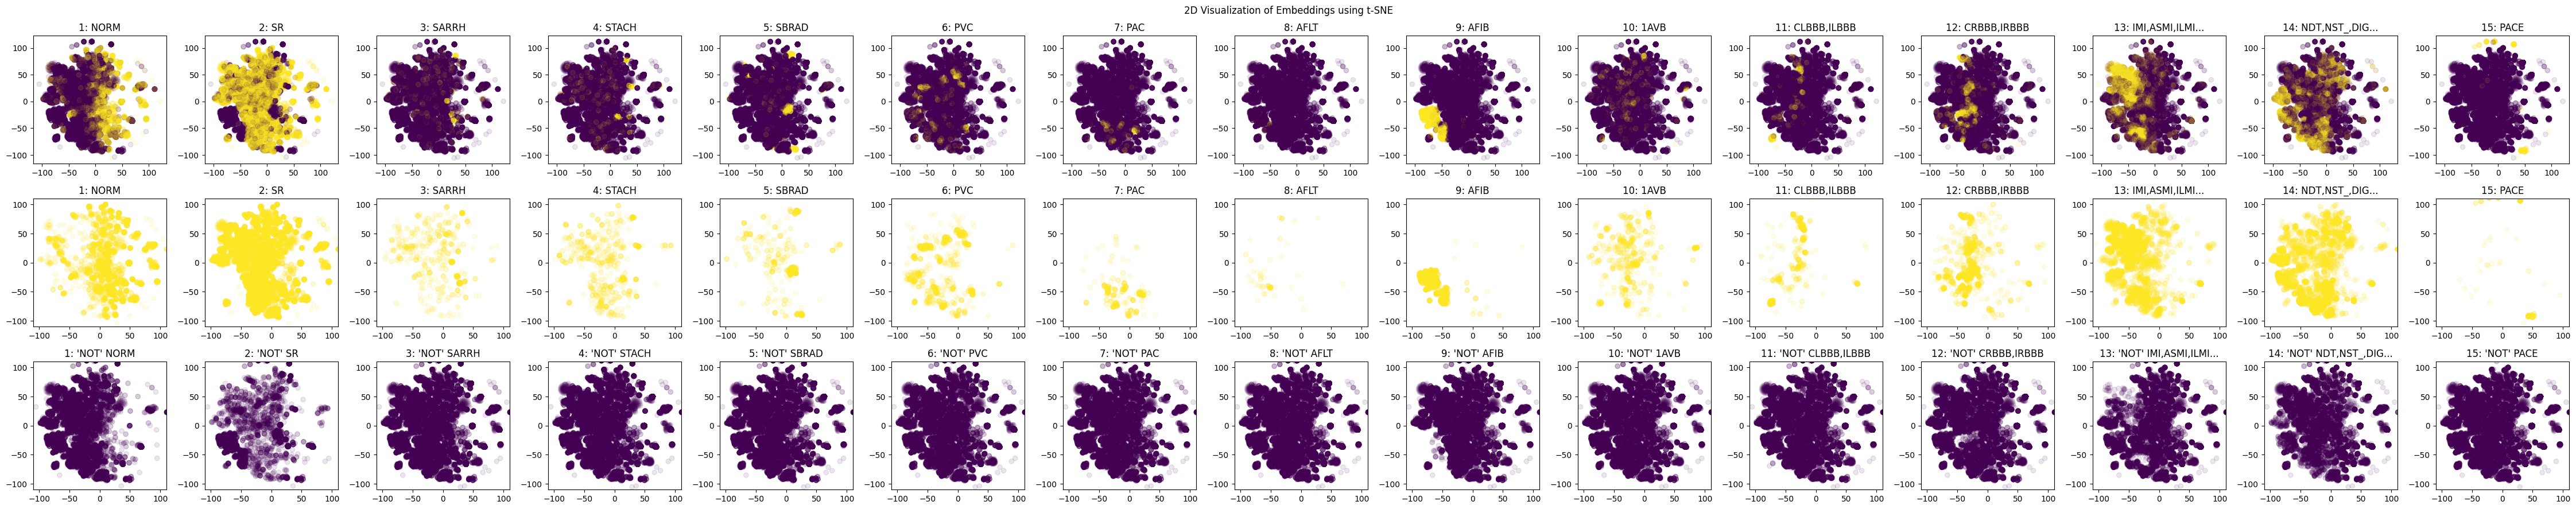

In [56]:
# Visualize the embeddings
fig, ax = plt.subplots(3, 15, figsize=(45, 9))
viridis = mpl.colormaps['viridis'].resampled(2)

for label_idx, label_name_iter in enumerate(label_names):

    # Both together
    ax_to_plot = ax[0, label_idx]
    title_for_label = f"{label_idx + 1}: {label_name_iter}"
    ax_to_plot.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        label=title_for_label,
        alpha=0.1,
        c=viridis((d_15_labels[:, label_idx] == 1)),
    )
    ax_to_plot.set_title(title_for_label)

    # Positive for label
    ax_to_plot = ax[1, label_idx]
    d_indices = d_15_labels[:, label_idx] == 1
    title_for_label = f"{label_idx + 1}: {label_name_iter}"
    ax_to_plot.scatter(
        embeddings_2d[d_indices, 0],
        embeddings_2d[d_indices, 1],
        label=title_for_label,
        alpha=0.1,
        c=viridis(np.ones(d_indices.sum())),
    )
    ax_to_plot.set_title(title_for_label)
    ax_to_plot.set_xlim(-110, 110)
    ax_to_plot.set_ylim(-110, 110)

    # Negative for label
    ax_to_plot = ax[2, label_idx]
    d_indices = d_15_labels[:, label_idx] == 0
    title_for_label = f"{label_idx + 1}: \'NOT\' {label_name_iter}"
    ax_to_plot.scatter(
        embeddings_2d[d_indices, 0],
        embeddings_2d[d_indices, 1],
        label=title_for_label,
        alpha=0.1,
        c=viridis(np.zeros(d_indices.sum())),
    )
    ax_to_plot.set_title(title_for_label)
    ax_to_plot.set_xlim(-110, 110)
    ax_to_plot.set_ylim(-110, 110)

plt.suptitle("2D Visualization of Embeddings using t-SNE")
# plt.figlegend(loc="outside lower center", ncols=5)
plt.tight_layout()
plt.show()

#### 3d

In [ ]:
2+2

In [ ]:
tsne = TSNE(n_components=3, random_state=42)
embeddings_3d = tsne.fit_transform(encodings)
embeddings_3d.shape

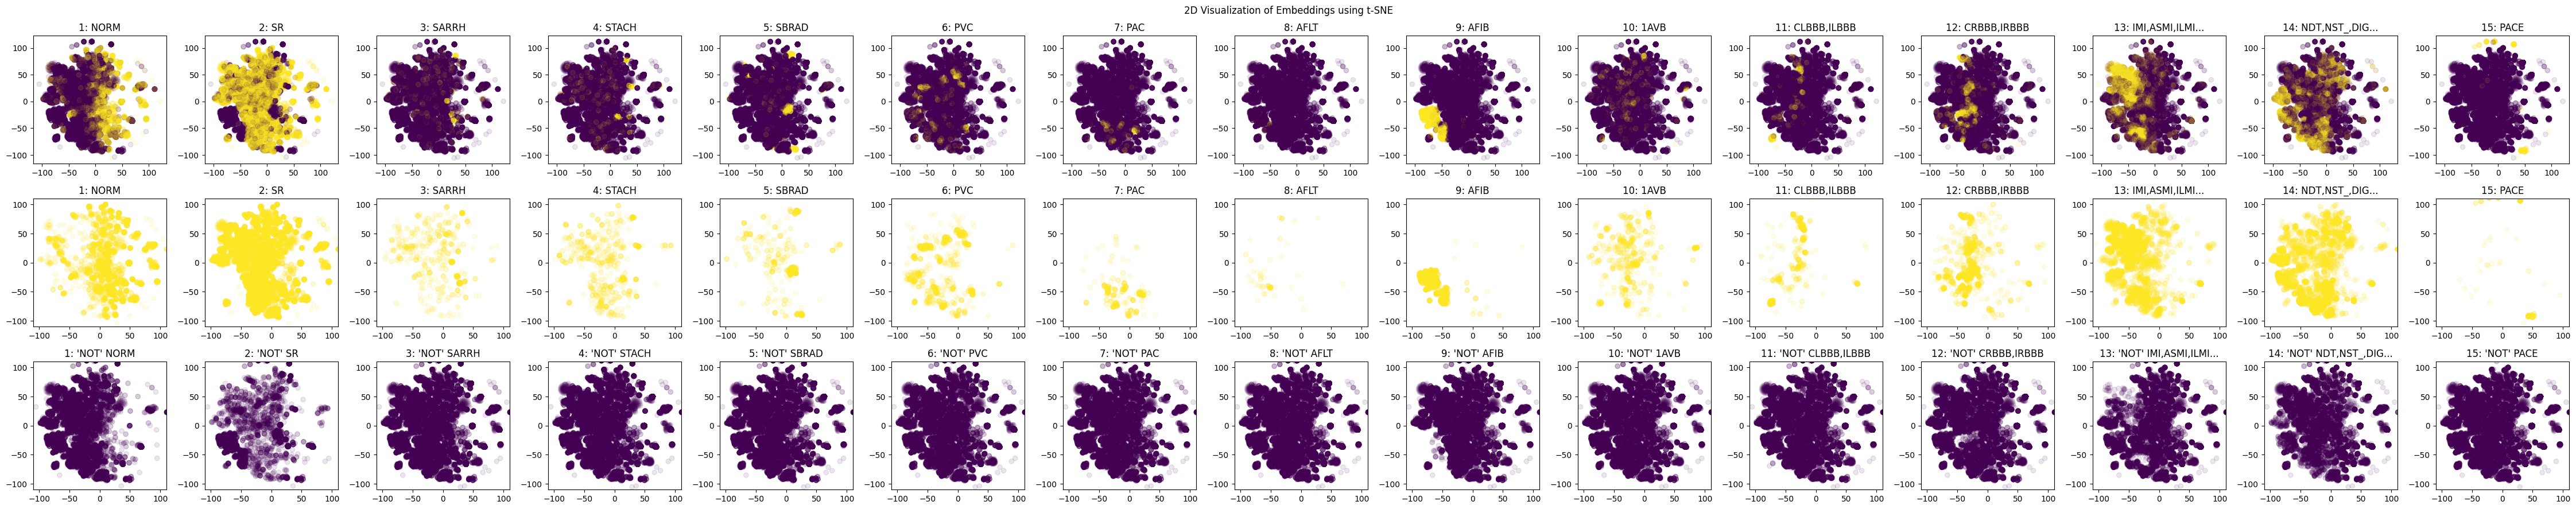

In [ ]:
# Visualize the embeddings
fig, ax = plt.subplots(3, 15, figsize=(45, 9))
viridis = mpl.colormaps['viridis'].resampled(2)

for label_idx, label_name_iter in enumerate(label_names):

    # Both together
    ax_to_plot = ax[0, label_idx]
    title_for_label = f"{label_idx + 1}: {label_name_iter}"
    ax_to_plot.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        label=title_for_label,
        alpha=0.1,
        c=viridis((d_15_labels[:, label_idx] == 1)),
    )
    ax_to_plot.set_title(title_for_label)

    # Positive for label
    ax_to_plot = ax[1, label_idx]
    d_indices = d_15_labels[:, label_idx] == 1
    title_for_label = f"{label_idx + 1}: {label_name_iter}"
    ax_to_plot.scatter(
        embeddings_2d[d_indices, 0],
        embeddings_2d[d_indices, 1],
        label=title_for_label,
        alpha=0.1,
        c=viridis(np.ones(d_indices.sum())),
    )
    ax_to_plot.set_title(title_for_label)
    ax_to_plot.set_xlim(-110, 110)
    ax_to_plot.set_ylim(-110, 110)

    # Negative for label
    ax_to_plot = ax[2, label_idx]
    d_indices = d_15_labels[:, label_idx] == 0
    title_for_label = f"{label_idx + 1}: \'NOT\' {label_name_iter}"
    ax_to_plot.scatter(
        embeddings_2d[d_indices, 0],
        embeddings_2d[d_indices, 1],
        label=title_for_label,
        alpha=0.1,
        c=viridis(np.zeros(d_indices.sum())),
    )
    ax_to_plot.set_title(title_for_label)
    ax_to_plot.set_xlim(-110, 110)
    ax_to_plot.set_ylim(-110, 110)

plt.suptitle("2D Visualization of Embeddings using t-SNE")
# plt.figlegend(loc="outside lower center", ncols=5)
plt.tight_layout()
plt.show()

### Visualize ECG

In [ ]:
x_arr = np.load(
    "/home/kumargirish/data/ptbxl_data_sssd-ecg/condition_all_separate_d+cn/data/ptbxl_train_data.npy"
)
x_arr.shape

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce embeddings to 2D
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(x_arr.reshape(x_arr.shape[0], -1))

In [ ]:
embeddings_2d.shape

In [ ]:
# Visualize the embeddings
fig, ax = plt.subplots(3, 5, figsize=(15, 9))
for label_idx, label_name_iter in enumerate(labels_15):
    ax_to_plot = ax[label_idx // 5, label_idx % 5]
    ax_to_plot.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        label=f"Label {label_idx + 1}: {', '.join(label_name_iter)}",
        alpha=0.1,
        c=(d_15_labels[:, label_idx] == 1),
        cmap="viridis",
    )
    ax_to_plot.set_title(f"{label_idx + 1}: {', '.join(label_name_iter)}")
plt.suptitle("2D Visualization of Embeddings using t-SNE")
# plt.figlegend(loc="outside lower center", ncols=5)
plt.tight_layout()
plt.show()

In [ ]:
# Visualize the embeddings
fig, ax = plt.subplots(3, 5, figsize=(15, 9))
for label_idx, label_name_iter in enumerate(labels_15):
    ax_to_plot = ax[label_idx // 5, label_idx % 5]
    d_indices = d_15_labels[:, label_idx] == 1
    ax_to_plot.scatter(
        embeddings_2d[d_indices, 0],
        embeddings_2d[d_indices, 1],
        label=f"{label_idx + 1}: {', '.join(label_name_iter)}",
        alpha=0.1,
    )
    ax_to_plot.set_title(f"{label_idx + 1}: {', '.join(label_name_iter)}")
plt.suptitle("2D Visualization of Embeddings using t-SNE")
# plt.figlegend(loc="outside lower center", ncols=5)
plt.tight_layout()
plt.show()

## Visualize Synthetic Data

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import ecg_plot

exp_name = "d_tog_15"
exp_name_with_cn = "d_tog_15_cn"
# exp_name = "condition_all_separate_d"
split = "test"

real_data_folder = (
    f"/home/kumargirish/data/ptbxl_data_sssd-ecg/{exp_name}"
)
real_label_path = os.path.join(real_data_folder, f"labels/ptbxl_{split}_labels.npy")
real_data_path = os.path.join(real_data_folder, f"data/ptbxl_{split}_data.npy")

synth_path = f"/home/kumargirish/output_sssd-ecg/{exp_name}/{exp_name}/ch256_T200_betaT0.02/synth_{split}_data/"
synth_path_with_cn = f"/home/kumargirish/output_sssd-ecg/{exp_name_with_cn}/{exp_name_with_cn}/ch256_T200_betaT0.02/synth_{split}_data/"


In [4]:
import matplotlib.pyplot as plt

def plot_ecg_comparison(real_data, synth_data, synth_with_cn_data, label, lead_names=None):
    """
    Plots side-by-side ECG comparisons for real and synthetic data.

    Parameters:
    - real_data: np.array or list, shape (12, time_points), Real ECG signal data.
    - synth_data: np.array or list, shape (12, time_points), Synthetic ECG signal data.
    - label: str, title of the plot.
    - lead_names: list of str (optional), names of the 12 leads.
    """
    if lead_names is None:
        lead_names = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

    fig, axes = plt.subplots(12, 3, figsize=(25, 10), sharex=True, sharey=True)

    for i in range(12):
        # Plot real_data on the left
        axes[i, 0].plot(real_data[i])
        axes[i, 0].set_ylabel(lead_names[i], fontsize=10, fontweight='bold')
        axes[i, 0].set_yticks([])  # Remove y-axis ticks for clarity
        axes[i, 0].set_xticks([]) if i < 11 else axes[i, 0].set_xlabel("Time (ms)")

        # Plot synth_data on the right
        axes[i, 1].plot(synth_data[i])
        axes[i, 1].set_yticks([])  # Remove y-axis ticks
        axes[i, 1].set_xticks([]) if i < 11 else axes[i, 1].set_xlabel("Time (ms)")

        # Plot synth_data with cn on the rightmost
        axes[i, 2].plot(synth_with_cn_data[i])
        axes[i, 2].set_yticks([])  # Remove y-axis ticks
        axes[i, 2].set_xticks([]) if i < 11 else axes[i, 1].set_xlabel("Time (ms)")

    # Titles for columns
    axes[0, 0].set_title("Real Data", fontsize=12, fontweight='bold')
    axes[0, 1].set_title("Synthetic Data", fontsize=12, fontweight="bold")
    axes[0, 2].set_title("Synthetic Data With CN", fontsize=12, fontweight="bold")

    # Add main title
    plt.suptitle(label, fontsize=14, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.98])  # Adjust layout to fit title
    plt.show()

#### Load data based on index to compare

In [10]:
# Finding total length of synth data
total_synth_samples = 0
for f in os.listdir(synth_path):
    if f.endswith("_samples.npy"):
        temp = len(np.load(os.path.join(synth_path, f)))
        print(f"Length of {f}: {temp}")
        total_synth_samples+=temp
print(f"Total number of samples in synth data: {total_synth_samples}")
        

Length of 2_samples.npy: 400
Length of 1_samples.npy: 400
Length of 5_samples.npy: 198
Length of 3_samples.npy: 400
Length of 4_samples.npy: 400
Length of 0_samples.npy: 400
Total number of samples in synth data: 2198


Synth file index:  0 . Index within selected file:  5
(2198, 12, 1000)
(400, 12, 1000)
(400, 12, 1000)


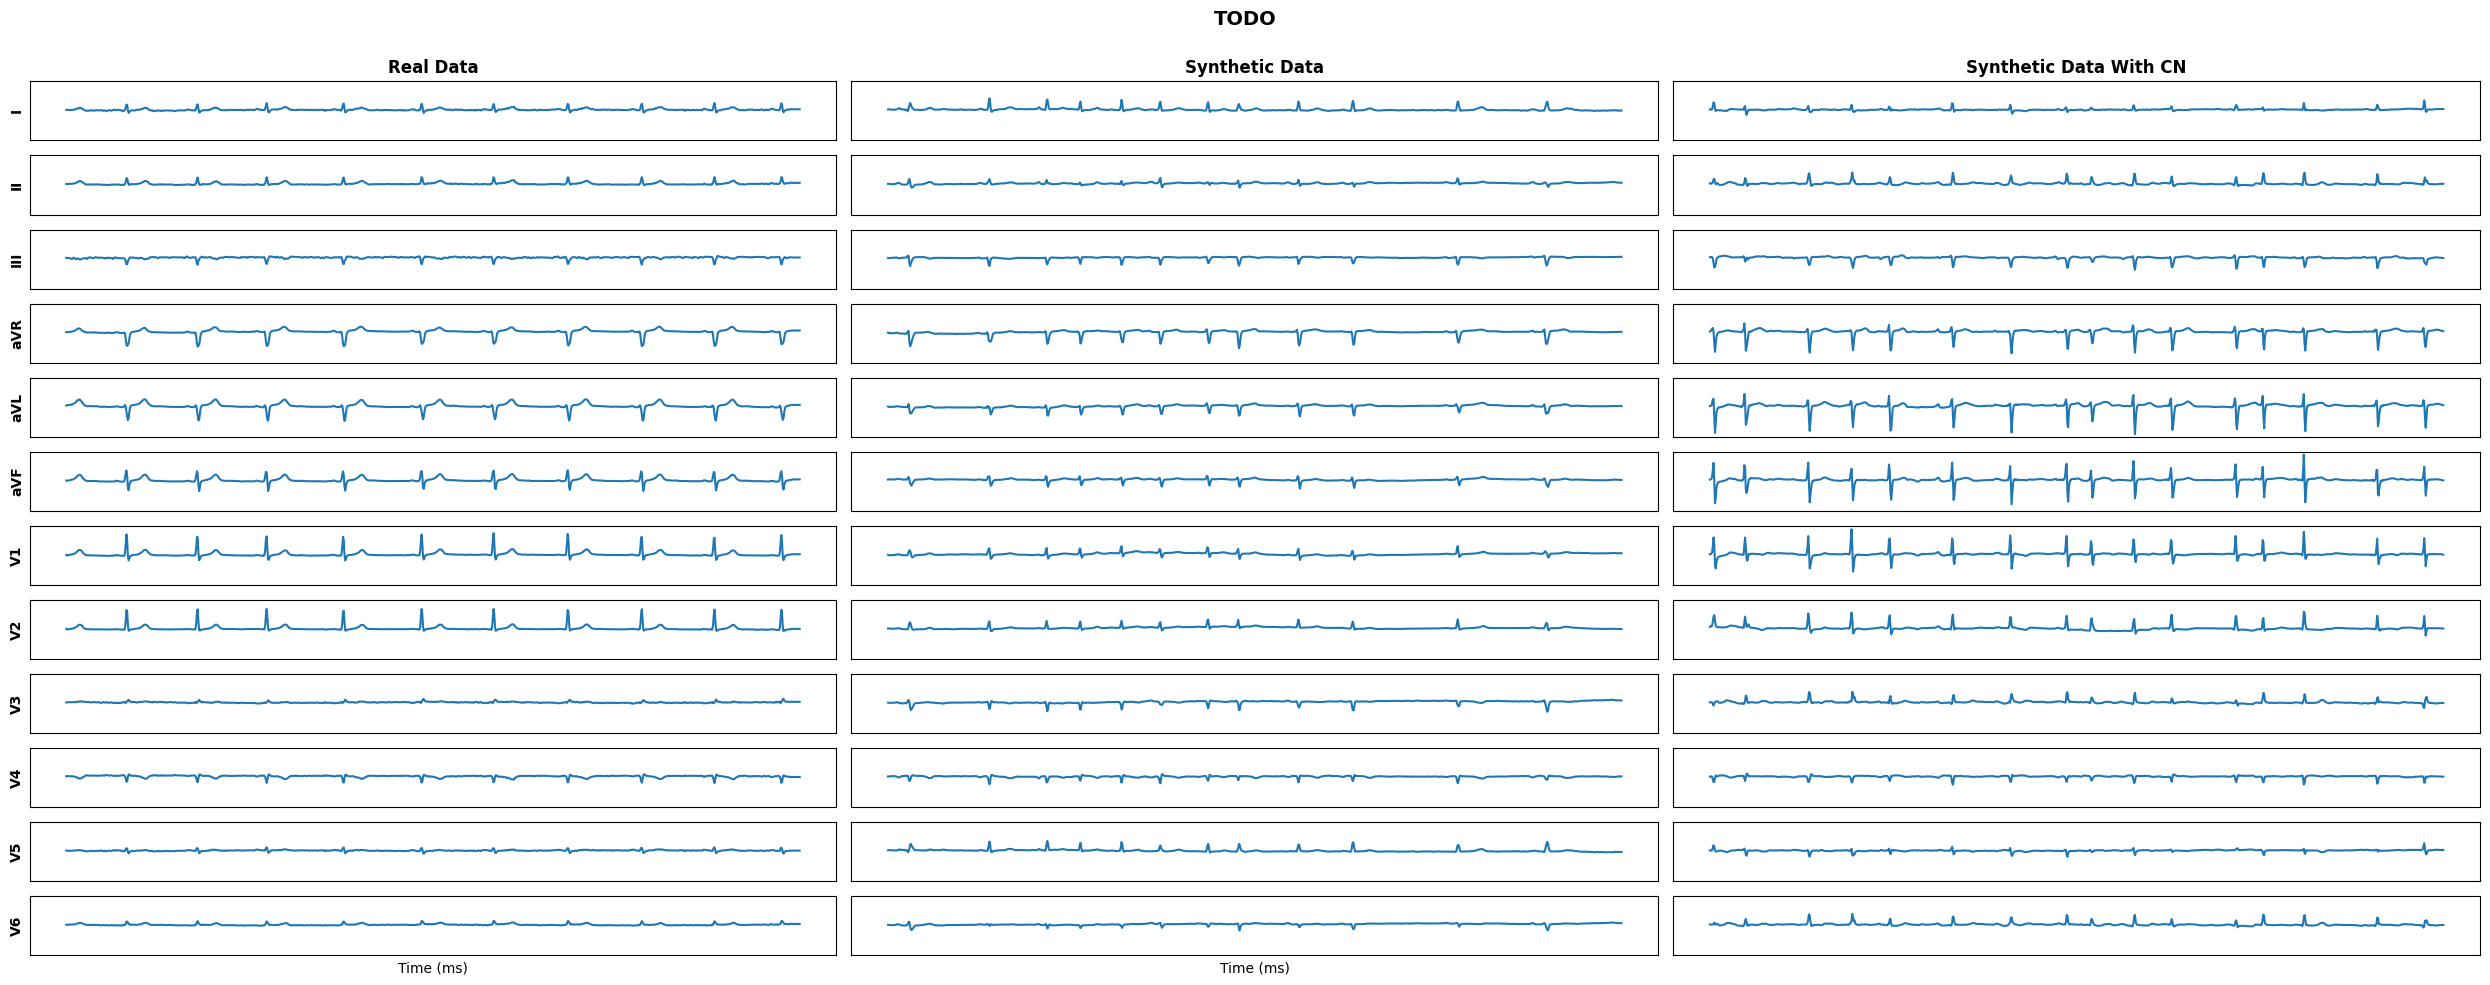

In [13]:
real_idx = 5
synth_file_idx = int(real_idx/400)
synth_idx_in_file = real_idx % 400
print("Synth file index: ", synth_file_idx, ". Index within selected file: ", synth_idx_in_file)
synth_data_file = os.path.join(synth_path, f"{synth_file_idx}_samples.npy")
synth_label_file = os.path.join(synth_path, f"{synth_file_idx}_labels.npy")

synth_with_cn_data_file = os.path.join(synth_path_with_cn, f"{synth_file_idx}_samples.npy") 
synth_with_cn_label_file = os.path.join(synth_path_with_cn, f"{synth_file_idx}_labels.npy")
real_data = np.load(real_data_path)
synth_data = np.load(synth_data_file)
synth_with_cn_data = np.load(synth_with_cn_data_file)
print(real_data.shape)
print(synth_data.shape)
print(synth_with_cn_data.shape)
plot_ecg_comparison(
    real_data[real_idx].reshape(12, -1),
    synth_data[synth_idx_in_file].reshape(12, -1),
    synth_with_cn_data[synth_idx_in_file].reshape(12, -1),
    "TODO",
)